# 10 — Specific functional enrichment and IL12A check

This notebook fixes two remaining issues.

**1. IL12A had only one link in the original network.** IL12A is half of the IL-12 protein, so this is suspicious. Was the gene name wrongly mapped by STRING, or is something else going on?

**2. The enrichment in notebook 06 was not informative.** Two problems:

- The top term for both communities was "Cytokine activity", which is obvious since every gene in the panel is a cytokine.
- Some terms come from text-mining-based categories. For example, the **COMPARTMENTS** category reported the original community 0 as enriched for the "interleukin-12 complex" with IL6, TNF and CCL2, which are not part of IL-12. This is the same co-citation bias removed in notebook 08.

**Fix:** keep only curated categories, remove generic terms, keep only terms **specific** to one community, and repeat the test using the 21 cytokines as background.

Run notebook 08 first (this notebook uses its files). An internet connection is needed once; STRING results are then saved in `data/raw/enrichment/`.

In [1]:
import os
import time
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

RAW_FILE = "../data/raw/string_network_all_channels.csv"
CACHE_DIR = "../data/raw/enrichment"
OUT_DIR = "../data/processed"
os.makedirs(CACHE_DIR, exist_ok=True)

PRIOR = 0.041
ALL_CHANNELS = ["nscore", "fscore", "pscore", "ascore", "escore", "dscore", "tscore"]


def combine_channels(df, channels, prior=PRIOR):
    corrected = ((df[channels] - prior) / (1 - prior)).clip(lower=0)
    combined = 1 - (1 - corrected).prod(axis=1)
    return combined * (1 - prior) + prior


raw = pd.read_csv(RAW_FILE)
raw["pair"] = raw.apply(lambda r: tuple(sorted([r["preferredName_A"], r["preferredName_B"]])), axis=1)
raw = raw.drop_duplicates("pair").reset_index(drop=True)
raw["score_all"] = combine_channels(raw, ALL_CHANNELS)
raw["score_expdb"] = combine_channels(raw, ["escore", "dscore"])

# STRING identifier of each cytokine (used for the background in Part 2)
ids = pd.concat([
    raw[["preferredName_A", "stringId_A"]].set_axis(["gene", "string_id"], axis=1),
    raw[["preferredName_B", "stringId_B"]].set_axis(["gene", "string_id"], axis=1),
]).drop_duplicates().set_index("gene")["string_id"]
print(f"{len(ids)} cytokines with a STRING identifier")

21 cytokines with a STRING identifier


## Part 1 — Why did IL12A have only one link?

If STRING had mapped "IL12A" to the wrong protein, IL12A would have no experimental partners at all. We check three things:

1. Which STRING protein "IL12A" was mapped to.
2. How many partners IL12A has in each network.
3. Its experimental, database and text-mining scores compared with other cytokines.

In [2]:
print("STRING identifier for IL12A:", ids.get("IL12A", "NOT FOUND"))
print("STRING identifier for IL12B:", ids.get("IL12B", "NOT FOUND"))
print("(Check on string-db.org that this identifier is 'Interleukin-12 subunit alpha'.)\n")

il12a = raw[(raw["preferredName_A"] == "IL12A") | (raw["preferredName_B"] == "IL12A")].copy()
il12a["partner"] = il12a.apply(
    lambda r: r["preferredName_B"] if r["preferredName_A"] == "IL12A" else r["preferredName_A"], axis=1)

print(f"Partners with all channels >= 0.7 (old network): {(il12a['score_all'] >= 0.7).sum()}")
print(f"Partners with experimental + database >= 0.4 (new network): {(il12a['score_expdb'] >= 0.4).sum()}\n")

il12a[["partner", "escore", "dscore", "tscore", "score_all", "score_expdb"]] \
    .sort_values("score_expdb", ascending=False).round(3)

STRING identifier for IL12A: 9606.ENSP00000303231
STRING identifier for IL12B: 9606.ENSP00000231228
(Check on string-db.org that this identifier is 'Interleukin-12 subunit alpha'.)

Partners with all channels >= 0.7 (old network): 2
Partners with experimental + database >= 0.4 (new network): 10



,partner,escore,dscore,tscore,score_all,score_expdb
104,IL12B,0.996,0.9,0.826,1.000,1.000
72,IL23A,0.000,0.9,0.422,0.942,0.900
177,IL6,0.000,0.4,0.361,0.636,0.400
143,IL1B,0.000,0.4,0.310,0.594,0.400
21,CCL2,0.000,0.4,0.194,0.499,0.400
175,IL13,0.000,0.4,0.251,0.556,0.400
176,TNF,0.000,0.4,0.365,0.617,0.400
173,CXCL8,0.000,0.4,0.168,0.498,0.400
174,CXCL10,0.000,0.4,0.213,0.525,0.400
178,IL10,0.000,0.4,0.400,0.640,0.400


In [3]:
# Compare IL12A with every other cytokine: mean channel scores over its pairs
rows = []
for gene in ids.index:
    sub = raw[(raw["preferredName_A"] == gene) | (raw["preferredName_B"] == gene)]
    rows.append({
        "cytokine": gene,
        "mean_text_mining": sub["tscore"].mean(),
        "mean_experimental": sub["escore"].mean(),
        "mean_database": sub["dscore"].mean(),
    })
channel_profile = pd.DataFrame(rows).sort_values("mean_text_mining").reset_index(drop=True)
channel_profile["text_mining_rank"] = range(1, len(channel_profile) + 1)
channel_profile.round(3)

,cytokine,mean_text_mining,mean_experimental,mean_database,text_mining_rank
0,IL12A,0.304,0.077,0.294,1
1,IL12B,0.417,0.100,0.250,2
2,IL23A,0.549,0.050,0.170,3
3,IL1RN,0.579,0.034,0.021,4
4,CCL11,0.705,0.105,0.000,5
5,IL22,0.724,0.000,0.045,6
6,CCL2,0.745,0.100,0.200,7
7,IL9,0.763,0.000,0.095,8
8,TGFB1,0.770,0.000,0.080,9
9,CXCL10,0.777,0.050,0.165,10


**How to read this:** if IL12A has normal experimental/database scores but one of the **lowest text-mining scores**, the name mapping is correct. The low degree came from text mining: papers usually write "IL-12" or "p35" rather than "IL12A", so STRING's text mining credits the whole protein (or IL12B) instead. This is another example of the bias found in notebook 08.

## Part 2 — Specific functional enrichment

### Method

1. **Curated categories only:** GO Biological Process, GO Molecular Function, GO Cellular Component, KEGG, Reactome and WikiPathways. We drop COMPARTMENTS, TISSUES and DISEASES (partly built from text mining), and PubMed, keywords and protein domains (not pathways).
2. **Remove broad terms:** terms with more than 500 human genes (for example "Extracellular region", about 2,000 genes) say little.
3. **Keep specific terms:** a term significant (FDR < 0.05) in **every** community of a partition is generic (like "Cytokine activity") and is removed. We keep terms significant in one community only.
4. **Panel background (robustness check):** we repeat the test using the 21 cytokines as background instead of the whole genome. Then "Cytokine activity" cannot be enriched by construction, and only terms that separate one group from the other cytokines remain. With 3–7 genes per group the power is low, so few terms are expected to pass.

We run this for both partitions: the original 2 communities (notebook 03) and the 5 evidence-filtered communities (notebook 08).

In [4]:
CURATED = {
    "Process": "GO Process",
    "Function": "GO Function",
    "Component": "GO Component",
    "KEGG": "KEGG",
    "RCTM": "Reactome",
    "WikiPathways": "WikiPathways",
}
MAX_TERM_SIZE = 500
FDR_CUTOFF = 0.05


def string_enrichment(genes, cache_name, background_ids=None):
    """STRING enrichment for a gene list; results are cached on disk."""
    path = os.path.join(CACHE_DIR, f"{cache_name}.csv")
    if os.path.exists(path):
        try:
            return pd.read_csv(path)
        except pd.errors.EmptyDataError:   # STRING returned no term
            return pd.DataFrame()
    data = {
        "identifiers": "\r".join(genes),
        "species": 9606,
        "caller_identity": "portfolio_project_cytokines",
    }
    if background_ids is not None:
        data["background_string_identifiers"] = "\r".join(background_ids)
    response = requests.post("https://string-db.org/api/tsv/enrichment", data=data, timeout=60)
    response.raise_for_status()
    df = pd.read_csv(StringIO(response.text), sep="\t") if response.text.strip() else pd.DataFrame()
    df.to_csv(path, index=False)
    time.sleep(1)   # be polite to the STRING server
    return df


partitions = {
    "original": pd.read_csv(os.path.join(OUT_DIR, "community_assignments.csv"))[["cytokine", "community_id"]],
    "filtered": pd.read_csv(os.path.join(OUT_DIR, "community_assignments_evidence_filtered.csv")),
}
partitions["filtered"] = partitions["filtered"][partitions["filtered"]["community_id"] >= 0]

enrich = []
for pname, assign in partitions.items():
    for cid, group in assign.groupby("community_id"):
        genes = sorted(group["cytokine"])
        for bg_name, bg in [("genome", None), ("panel", list(ids.values))]:
            df = string_enrichment(genes, f"{pname}_c{cid}_{bg_name}", bg)
            if df.empty:
                continue
            df = df.assign(partition=pname, community=cid, background=bg_name,
                           members=", ".join(genes))
            enrich.append(df)
        print(f"{pname} community {cid} ({len(genes)} genes): done")

enrich = pd.concat(enrich, ignore_index=True)
print(f"\n{len(enrich)} terms returned in total")

original community 0 (14 genes): done
original community 1 (7 genes): done
filtered community 0 (5 genes): done
filtered community 1 (5 genes): done
filtered community 2 (4 genes): done
filtered community 3 (4 genes): done
filtered community 4 (3 genes): done

2317 terms returned in total


In [5]:
def specific_terms(enrich, partition, background="genome"):
    df = enrich[(enrich["partition"] == partition) & (enrich["background"] == background)].copy()
    n_comm = partitions[partition]["community_id"].nunique()
    report = {"returned": len(df)}

    df = df[df["category"].isin(CURATED)]
    report["curated"] = len(df)
    df = df[df["fdr"] < FDR_CUTOFF]
    report["significant"] = len(df)
    df = df[df["number_of_genes_in_background"] <= MAX_TERM_SIZE]
    report["not_too_broad"] = len(df)

    n_hits = df.groupby("term")["community"].nunique()
    generic = n_hits[n_hits == n_comm].index if n_comm > 1 else []
    generic_names = sorted(df[df["term"].isin(generic)]["description"].unique())
    df = df[df["term"].map(n_hits) == 1]
    report["specific"] = len(df)

    df["source"] = df["category"].map(CURATED)
    df = df.sort_values(["community", "fdr"])
    return df, report, generic_names


summary = {}
for pname in partitions:
    spec, report, generic = specific_terms(enrich, pname)
    summary[pname] = spec
    spec.to_csv(os.path.join(OUT_DIR, f"enrichment_specific_{pname}.csv"), index=False)
    print(f"=== {pname} partition ===")
    print("Filtering steps:", report)
    print(f"Generic terms removed (significant in every community): {len(generic)}")
    print("  examples:", generic[:5], "\n")

=== original partition ===
Filtering steps: {'returned': 1120, 'curated': 734, 'significant': 734, 'not_too_broad': 612, 'specific': 414}
Generic terms removed (significant in every community): 98
  examples: ['Acute viral myocarditis', 'Adaptive immune response', 'African trypanosomiasis', 'Alcoholic liver disease', 'Allograft rejection'] 

=== filtered partition ===
Filtering steps: {'returned': 1192, 'curated': 633, 'significant': 633, 'not_too_broad': 572, 'specific': 274}
Generic terms removed (significant in every community): 3
  examples: ['Cytokine-cytokine receptor interaction', 'Immune infiltration in pancreatic cancer', 'Overview of proinflammatory and profibrotic mediators'] 



### Top specific terms per community

For each community: the 5 most significant terms found **only** in that community.

In [6]:
def show_top(pname, n=5):
    spec = summary[pname]
    assign = partitions[pname]
    for cid, group in assign.groupby("community_id"):
        members = ", ".join(sorted(group["cytokine"]))
        top = spec[spec["community"] == cid].head(n)
        print(f"\n--- {pname} community {cid}: {members}")
        if top.empty:
            print("    no specific term")
        for _, r in top.iterrows():
            print(f"    [{r['source']}] {r['description']}  (FDR {r['fdr']:.1e}; genes: {r['preferredNames']})")


show_top("original")


--- original community 0: CCL11, CCL2, CXCL10, CXCL8, IL13, IL1B, IL1RN, IL2, IL4, IL5, IL6, IL9, TGFB1, TNF
    [WikiPathways] Lung fibrosis  (FDR 6.1e-20; genes: TGFB1,CCL2,IL4,IL5,IL1B,CCL11,IL13,CXCL8,IL6,TNF)
    [WikiPathways] COVID 19 adverse outcome pathway  (FDR 3.5e-16; genes: CCL2,IL2,IL1B,CXCL10,CXCL8,IL6,TNF)
    [WikiPathways] Spinal cord injury  (FDR 2.7e-15; genes: TGFB1,CCL2,IL2,IL4,IL1B,CXCL10,CXCL8,IL6,TNF)
    [KEGG] Asthma  (FDR 6.5e-12; genes: IL4,IL5,IL9,CCL11,IL13,TNF)
    [KEGG] Viral protein interaction with cytokine and cytokine receptor  (FDR 2.3e-11; genes: CCL2,IL2,CCL11,CXCL10,CXCL8,IL6,TNF)

--- original community 1: IFNG, IL10, IL12A, IL12B, IL17A, IL22, IL23A
    [WikiPathways] IL23 inhibitors in inflammatory bowel disease  (FDR 6.8e-12; genes: IL23A,IFNG,IL12B,IL22,IL17A)
    [WikiPathways] Lupus therapies  (FDR 3.8e-11; genes: IL23A,IFNG,IL12B,IL12A,IL17A)
    [Reactome] Interleukin-12 family signaling  (FDR 7.4e-09; genes: IL23A,IFNG,IL12B,IL12A,IL

In [7]:
show_top("filtered")


--- filtered community 0: IFNG, IL13, IL1B, IL6, TNF
    [WikiPathways] Tryptophan kynurenine pathway in post COVID syndrome  (FDR 1.4e-09; genes: IFNG,IL1B,IL6,TNF)
    [KEGG] Graft-versus-host disease  (FDR 9.0e-09; genes: IFNG,IL1B,IL6,TNF)
    [WikiPathways] Vitamin B12 metabolism  (FDR 3.2e-08; genes: IFNG,IL1B,IL6,TNF)
    [WikiPathways] Selenium micronutrient network  (FDR 1.3e-07; genes: IFNG,IL1B,IL6,TNF)
    [WikiPathways] LTF danger signal response pathway  (FDR 5.8e-07; genes: IL1B,IL6,TNF)

--- filtered community 1: IL17A, IL2, IL4, IL5, IL9
    [WikiPathways] Inflammatory response pathway  (FDR 4.7e-06; genes: IL2,IL4,IL5)
    [KEGG] Autoimmune thyroid disease  (FDR 1.0e-05; genes: IL2,IL4,IL5)
    [GO Function] Growth factor activity  (FDR 2.3e-05; genes: IL2,IL4,IL5,IL9)
    [GO Function] Growth factor receptor binding  (FDR 2.3e-05; genes: IL2,IL4,IL5,IL9)
    [Reactome] Interleukin-2 family signaling  (FDR 1.0e-04; genes: IL2,IL5,IL9)

--- filtered community 2: IL10,

### Visual summary

Each column is a community of the filtered partition, each row a top specific term. The color shows significance (−log10 FDR): darker = more significant.

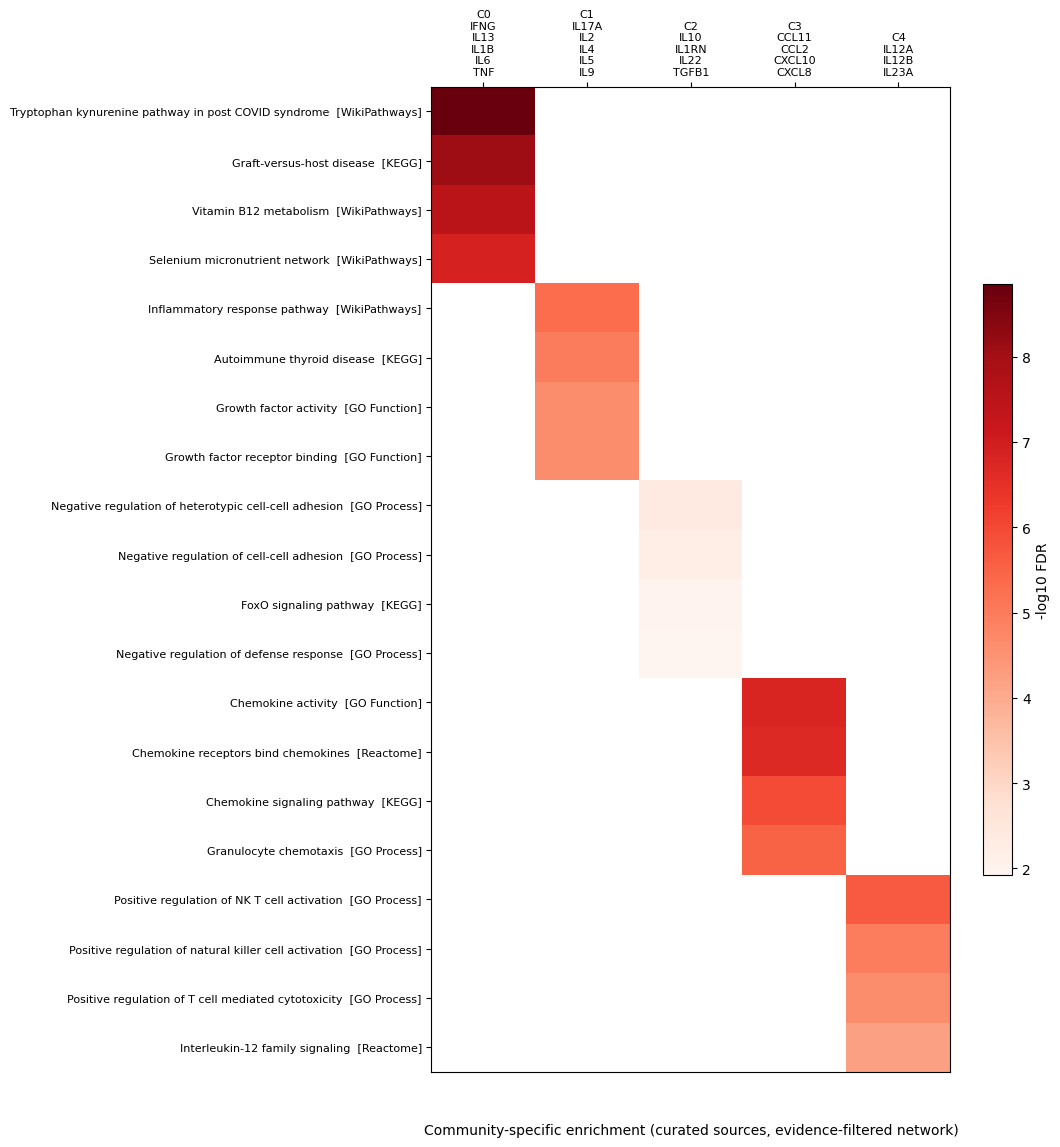

In [8]:
spec = summary["filtered"]
top_terms = spec.groupby("community").head(4)
if top_terms.empty:
    print("No specific term to plot.")
else:
    labels = (top_terms["description"].str.slice(0, 55) + "  [" + top_terms["source"] + "]").tolist()
    comms = sorted(partitions["filtered"]["community_id"].unique())
    matrix = np.full((len(top_terms), len(comms)), np.nan)
    for i, (_, r) in enumerate(top_terms.iterrows()):
        matrix[i, comms.index(r["community"])] = -np.log10(r["fdr"])

    names = []
    for c in comms:
        members = sorted(partitions["filtered"].query("community_id == @c")["cytokine"])
        names.append(f"C{c}\n" + "\n".join(members))

    fig, ax = plt.subplots(figsize=(3 + 1.6 * len(comms), 0.45 * len(labels) + 2.5))
    im = ax.imshow(matrix, cmap="Reds", aspect="auto")
    ax.set_xticks(range(len(comms)))
    ax.set_xticklabels(names, fontsize=8)
    ax.xaxis.tick_top()
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    plt.colorbar(im, ax=ax, label="-log10 FDR", shrink=0.6)
    ax.set_title("Community-specific enrichment (curated sources, evidence-filtered network)",
                 fontsize=10, pad=12, y=-0.08)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "enrichment_specific_filtered.png"), dpi=200, bbox_inches="tight")
    plt.show()

### Robustness check: panel background

Same filtering, but the test compares each community with the other cytokines of the panel instead of the whole genome.

In [9]:
for pname in partitions:
    spec_bg, report_bg, _ = specific_terms(enrich, pname, background="panel")
    print(f"=== {pname} partition, panel background ===")
    print("Filtering steps:", report_bg)
    if spec_bg.empty:
        print("No term passes FDR < 0.05 against the panel background.\n")
    else:
        print(spec_bg[["community", "source", "description", "preferredNames", "fdr"]].to_string(index=False), "\n")
    spec_bg.to_csv(os.path.join(OUT_DIR, f"enrichment_specific_{pname}_panel_background.csv"), index=False)

=== original partition, panel background ===
Filtering steps: {'returned': 0, 'curated': 0, 'significant': 0, 'not_too_broad': 0, 'specific': 0}
No term passes FDR < 0.05 against the panel background.

=== filtered partition, panel background ===
Filtering steps: {'returned': 5, 'curated': 0, 'significant': 0, 'not_too_broad': 0, 'specific': 0}
No term passes FDR < 0.05 against the panel background.



**How to read this:** a term passing here separates its community from the other cytokines, not just from random genes. If nothing passes, it does not mean the communities are meaningless: groups of 3–7 genes out of 21 rarely reach significance. Report the genome-background specific terms as the main result and say that the panel-background test had low power.

## Conclusion (fill in after running)

**IL12A**
- Mapped to: ___ (correct / incorrect)
- Partners: old network ___, new network ___
- Text-mining rank among the 21 cytokines: ___ → explanation: ___

**Enrichment**
- Generic terms removed: ___ (e.g. ___)
- Original community 0 specific terms: ___
- Original community 1 specific terms: ___
- Filtered communities, one line each: ___
- Panel background: ___ terms pass